<a href="https://colab.research.google.com/github/Nilamsari01/Pengolahan_Citra_Digital/blob/main/Tugas6_PCD_NILAM_SARI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# LAPORAN & ANALISIS MINI PROJECT: SIGNATURE DETECTION

**Nama:** Nilam Sari  
**NIM:** F1G124046  
**Program Studi:** Ilmu Komputer

---
# Mini Project Deteksi Keberadaan Tanda Tangan

Mini project ini dibuat untuk mendeteksi keberadaan tanda tangan kepala sekolah pada area tertentu dari citra dokumen menggunakan teknik pengolahan citra digital.

Program menggunakan Python dan OpenCV dengan tahapan crop area tanda tangan, grayscale, thresholding, morphological operation, perhitungan piksel foreground, dan klasifikasi sederhana menjadi `SIGNATURE PRESENT` atau `SIGNATURE ABSENT`.

## Tujuan

Tujuan dari mini-project ini adalah:

1. Melakukan crop pada area tanda tangan kepala sekolah.
2. Mengubah citra hasil crop menjadi grayscale.
3. Menerapkan beberapa metode thresholding.
4. Membandingkan hasil Global Threshold, Otsu Threshold, dan Adaptive Threshold.
5. Menerapkan morphological operation berupa opening dan closing.
6. Menghitung jumlah piksel foreground.
7. Menghitung persentase area foreground.
8. Membuat aturan sederhana untuk menentukan keberadaan tanda tangan.
9. Menguji sistem menggunakan beberapa citra yang memiliki tanda tangan dan citra yang tidak memiliki tanda tangan.

## Metode yang Digunakan

### 1. Crop

Area tanda tangan dipisahkan dari keseluruhan dokumen agar proses analisis hanya dilakukan pada bagian yang relevan.

### 2. Grayscale

Citra hasil crop dikonversi dari citra berwarna menjadi grayscale. Citra grayscale memiliki satu nilai intensitas pada setiap piksel sehingga lebih mudah diproses menggunakan thresholding.

### 3. Global Threshold

Global threshold menggunakan satu nilai ambang untuk seluruh area citra. Piksel yang memenuhi kondisi threshold akan dikategorikan sebagai foreground, sedangkan piksel lainnya menjadi background.

### 4. Otsu Threshold

Otsu threshold menentukan nilai threshold secara otomatis berdasarkan distribusi intensitas citra. Metode ini digunakan untuk memperoleh pemisahan foreground dan background tanpa menentukan nilai threshold secara manual.

### 5. Adaptive Threshold

Adaptive threshold menentukan nilai threshold berdasarkan area lokal citra. Metode ini dapat membantu ketika pencahayaan pada dokumen tidak merata.

### 6. Morphological Operation

Morphological operation digunakan untuk memperbaiki hasil segmentasi.

Opening digunakan untuk mengurangi noise atau objek kecil yang tidak diperlukan.

Closing digunakan untuk menutup celah kecil pada objek foreground sehingga bagian objek yang terputus dapat menjadi lebih tersambung.

### 7. Foreground Pixel

Jumlah piksel foreground dihitung setelah proses segmentasi.

Foreground ratio dihitung menggunakan rumus:

Foreground Ratio = Jumlah Piksel Foreground / Jumlah Seluruh Piksel

Nilai tersebut digunakan sebagai salah satu karakteristik untuk menentukan keberadaan tanda tangan.

## Aturan Klasifikasi

Program menggunakan aturan sederhana:

Jika:

Foreground Ratio >= Threshold

maka:

SIGNATURE PRESENT

Sedangkan jika:

Foreground Ratio < Threshold

maka:

SIGNATURE ABSENT

Nilai threshold keputusan dapat disesuaikan berdasarkan hasil pengujian citra yang memiliki tanda tangan dan citra yang tidak memiliki tanda tangan.

## Mengapa Thresholding Diperlukan?

Thresholding diperlukan untuk memisahkan foreground dan background pada area tanda tangan.

Setelah citra dikonversi menjadi grayscale, masih terdapat berbagai nilai intensitas piksel. Thresholding mengubah citra tersebut menjadi citra biner sehingga bagian yang dianggap sebagai foreground dapat dipisahkan dari background.

Hasil segmentasi kemudian dapat digunakan untuk menghitung jumlah piksel foreground dan persentase area foreground. Informasi tersebut digunakan sebagai dasar untuk menentukan keberadaan tanda tangan.

## Masalah Threshold Terlalu Tinggi

Jika threshold terlalu tinggi, piksel tinta yang merupakan bagian dari tanda tangan dapat dianggap sebagai background.

Akibatnya:

- tanda tangan dapat menjadi terputus;
- sebagian tanda tangan dapat hilang;
- jumlah foreground menjadi terlalu sedikit;
- sistem dapat menghasilkan `SIGNATURE ABSENT` padahal tanda tangan ada.

## Masalah Threshold Terlalu Rendah

Jika threshold terlalu rendah, background atau noise dapat ikut dianggap sebagai foreground.

Akibatnya:

- noise ikut tersegmentasi;
- jumlah foreground menjadi terlalu banyak;
- area tanda tangan terlihat lebih besar;
- sistem dapat menghasilkan `SIGNATURE PRESENT` padahal tanda tangan tidak ada.


In [203]:
!pip install opencv-python-headless matplotlib pandas -q

In [204]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from google.colab import files
from pathlib import Path

print("Library berhasil di-load.")

Library berhasil di-load.


In [205]:
uploaded = files.upload()

image_files = list(uploaded.keys())

print("\nGambar yang berhasil di-upload:")
for name in image_files:
    print("-", name)

Saving ijazah3.jpg to ijazah3 (4).jpg
Saving ijazah2.jpg to ijazah2 (6).jpg

Gambar yang berhasil di-upload:
- ijazah3 (4).jpg
- ijazah2 (6).jpg


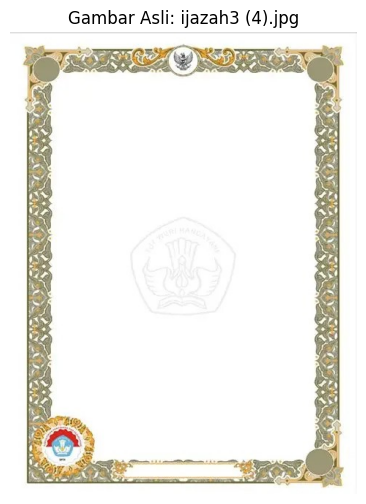

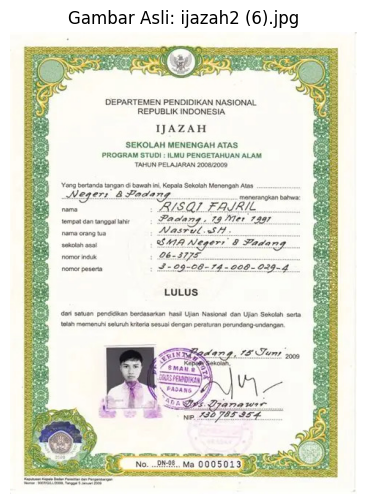

In [206]:
def show_uploaded_images(image_files):
    for filename in image_files:
        image = cv2.imread(filename)

        if image is None:
            print(f"Gagal membaca: {filename}")
            continue

        image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        plt.figure(figsize=(10, 6))
        plt.imshow(image_rgb)
        plt.title(f"Gambar Asli: {filename}")
        plt.axis("off")
        plt.show()


show_uploaded_images(image_files)

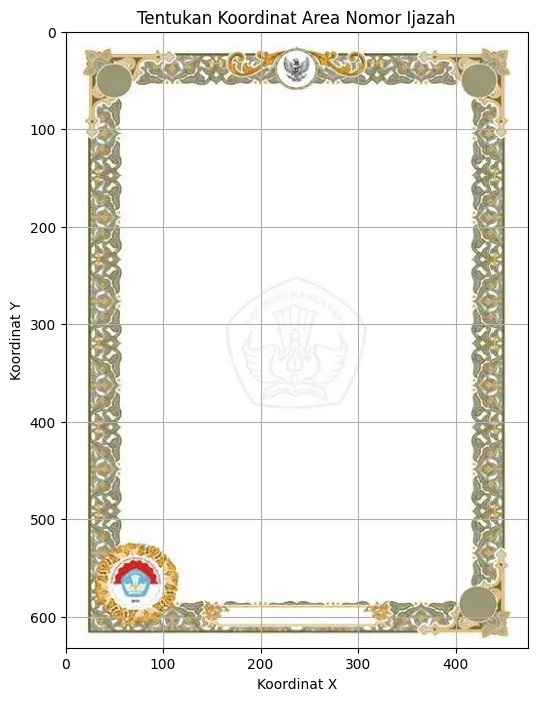

In [207]:
# Membaca salah satu gambar (misalnya gambar pertama)
img = cv2.imread(image_files[0])
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(12, 8))
plt.imshow(img_rgb)

plt.xlim(0, img.shape[1])
plt.ylim(img.shape[0], 0)

plt.xlabel("Koordinat X")
plt.ylabel("Koordinat Y")
plt.title("Tentukan Koordinat Area Nomor Ijazah")

plt.grid()
plt.show()

In [208]:
# ==========================================
# KOORDINAT RELATIF AREA TANDA TANGAN (PERSENTASE 0.0 s.d 1.0)
# ==========================================
# Contoh: 0.75 berarti 75% dari lebar atau tinggi gambar


x1_rel = 0.50
y1_rel = 0.72

x2_rel = 0.83
y2_rel = 0.80

In [209]:
def crop_signature_area(image, x1_rel, y1_rel, x2_rel, y2_rel):
    height, width = image.shape[:2]

    # Konversi koordinat relatif ke pixel asli
    x1 = int(x1_rel * width)
    x2 = int(x2_rel * width)
    y1 = int(y1_rel * height)
    y2 = int(y2_rel * height)

    # Memastikan koordinat tidak keluar dari ukuran gambar
    x1 = max(0, min(x1, width - 1))
    x2 = max(x1 + 1, min(x2, width))
    y1 = max(0, min(y1, height - 1))
    y2 = max(y1 + 1, min(y2, height))

    cropped = image[y1:y2, x1:x2]
    return cropped

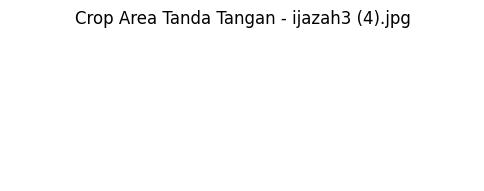

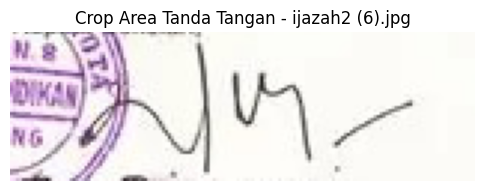

In [210]:
for filename in image_files:
    image = cv2.imread(filename)
    if image is None:
        print(f"Gagal membaca: {filename}")
        continue

    # Memotong menggunakan koordinat relatif
    cropped = crop_signature_area(image, x1_rel, y1_rel, x2_rel, y2_rel)
    cropped_rgb = cv2.cvtColor(cropped, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(6, 3))
    plt.imshow(cropped_rgb)
    plt.title(f"Crop Area Tanda Tangan - {filename}")
    plt.axis("off")
    plt.show()

In [211]:
def convert_to_grayscale(cropped):
    gray = cv2.cvtColor(cropped, cv2.COLOR_BGR2GRAY)
    return gray

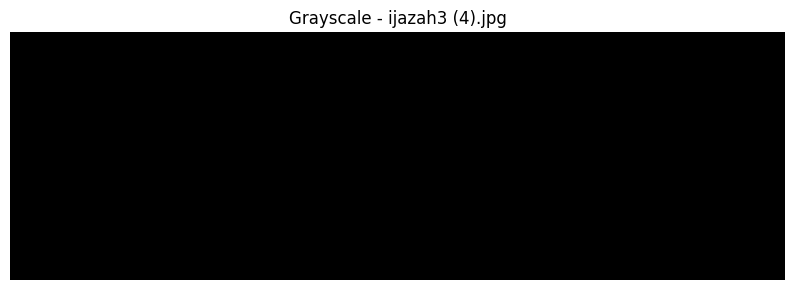

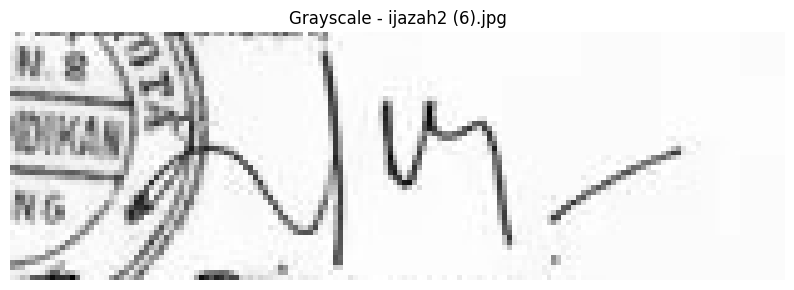

In [212]:
for filename in image_files:

    image = cv2.imread(filename)

    cropped = crop_signature_area(
        image,
         x1_rel, y1_rel, x2_rel, y2_rel
    )

    gray = convert_to_grayscale(cropped)

    plt.figure(figsize=(10, 4))
    plt.imshow(gray, cmap="gray")
    plt.title(f"Grayscale - {filename}")
    plt.axis("off")
    plt.show()

In [213]:
def apply_thresholding(gray):

    # Mengurangi sedikit noise sebelum thresholding
    blurred = cv2.GaussianBlur(gray, (5, 5), 0)

    # ==========================================
    # 1. GLOBAL THRESHOLD
    # ==========================================
    global_threshold_value = 127

    _, global_binary = cv2.threshold(
        blurred,
        global_threshold_value,
        255,
        cv2.THRESH_BINARY_INV
    )

    # ==========================================
    # 2. OTSU THRESHOLD
    # ==========================================
    otsu_value, otsu_binary = cv2.threshold(
        blurred,
        0,
        255,
        cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU
    )

    # ==========================================
    # 3. ADAPTIVE THRESHOLD
    # ==========================================
    adaptive_binary = cv2.adaptiveThreshold(
        blurred,
        255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY_INV,
        31,
        10
    )

    return {
        "Global": global_binary,
        "Otsu": otsu_binary,
        "Adaptive": adaptive_binary,
        "Otsu_Value": otsu_value
    }

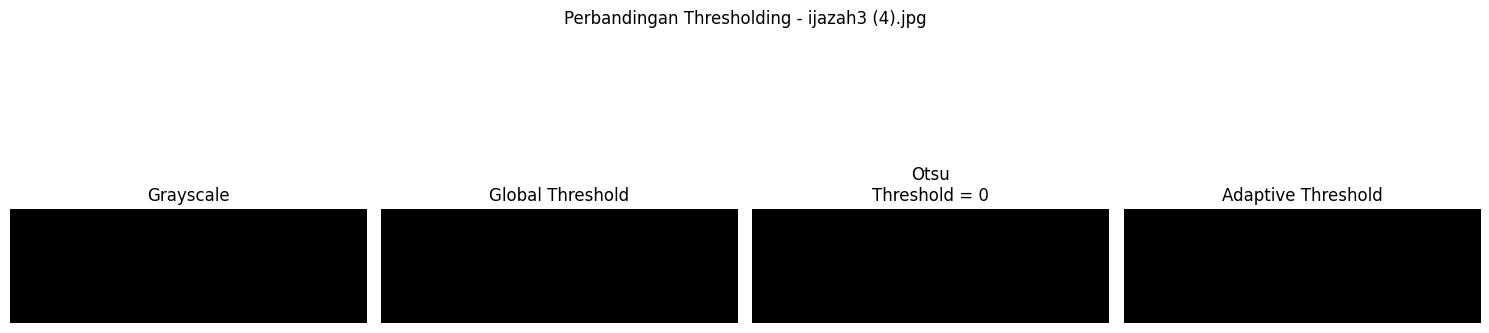

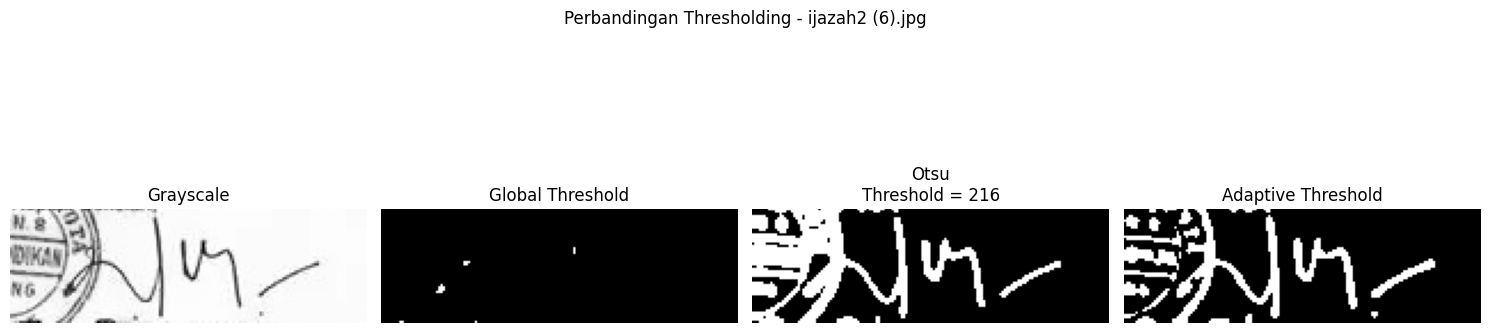

In [214]:
for filename in image_files:

    image = cv2.imread(filename)

    cropped = crop_signature_area(
        image,
        x1_rel, y1_rel, x2_rel, y2_rel
    )

    gray = convert_to_grayscale(cropped)

    results = apply_thresholding(gray)

    plt.figure(figsize=(15, 5))

    plt.subplot(1, 4, 1)
    plt.imshow(gray, cmap="gray")
    plt.title("Grayscale")
    plt.axis("off")

    plt.subplot(1, 4, 2)
    plt.imshow(results["Global"], cmap="gray")
    plt.title("Global Threshold")
    plt.axis("off")

    plt.subplot(1, 4, 3)
    plt.imshow(results["Otsu"], cmap="gray")
    plt.title(f"Otsu\nThreshold = {results['Otsu_Value']:.0f}")
    plt.axis("off")

    plt.subplot(1, 4, 4)
    plt.imshow(results["Adaptive"], cmap="gray")
    plt.title("Adaptive Threshold")
    plt.axis("off")

    plt.suptitle(f"Perbandingan Thresholding - {filename}")

    plt.tight_layout()
    plt.show()

In [215]:
def apply_morphology(binary):

    # Kernel 3x3
    kernel = np.ones((3, 3), np.uint8)

    # ==========================================
    # OPENING
    # ==========================================
    opening = cv2.morphologyEx(
        binary,
        cv2.MORPH_OPEN,
        kernel,
        iterations=1
    )

    # ==========================================
    # CLOSING
    # ==========================================
    closing = cv2.morphologyEx(
        opening,
        cv2.MORPH_CLOSE,
        kernel,
        iterations=1
    )

    return opening, closing

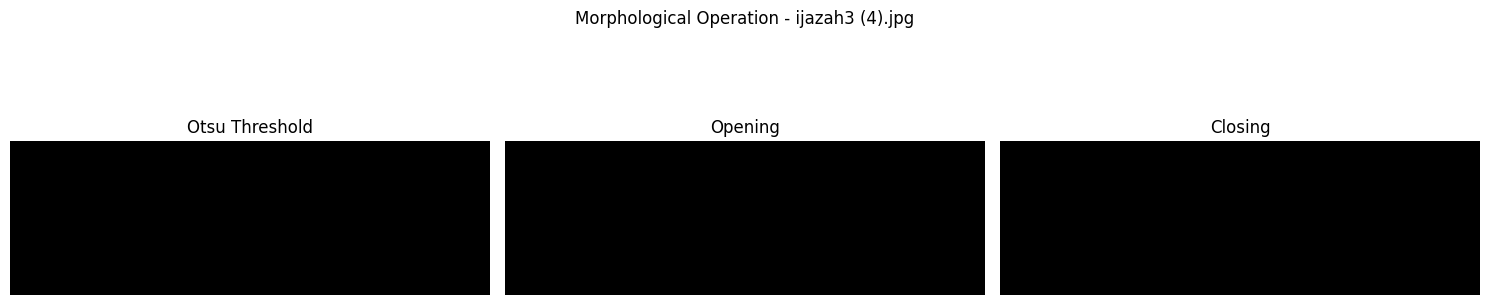

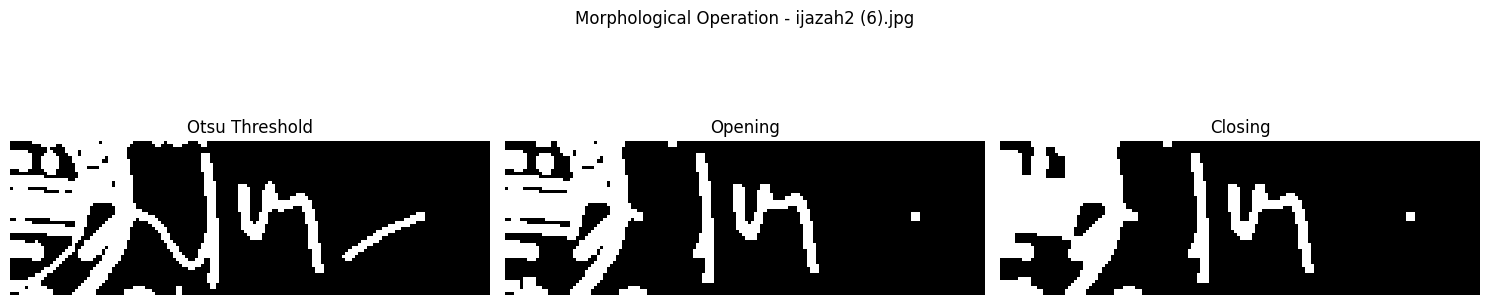

In [216]:
for filename in image_files:

    image = cv2.imread(filename)

    cropped = crop_signature_area(
        image,
        x1_rel, y1_rel, x2_rel, y2_rel
    )

    gray = convert_to_grayscale(cropped)

    thresholds = apply_thresholding(gray)

    # Kita gunakan Otsu untuk proses morphology
    otsu_binary = thresholds["Otsu"]

    opening, closing = apply_morphology(otsu_binary)

    plt.figure(figsize=(15, 4))

    plt.subplot(1, 3, 1)
    plt.imshow(otsu_binary, cmap="gray")
    plt.title("Otsu Threshold")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(opening, cmap="gray")
    plt.title("Opening")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow(closing, cmap="gray")
    plt.title("Closing")
    plt.axis("off")

    plt.suptitle(f"Morphological Operation - {filename}")

    plt.tight_layout()
    plt.show()

In [217]:
def calculate_foreground(binary):

    total_pixels = binary.size

    foreground_pixels = np.count_nonzero(binary)

    foreground_ratio = (
        foreground_pixels / total_pixels
    )

    foreground_percentage = (
        foreground_ratio * 100
    )

    return (
        total_pixels,
        foreground_pixels,
        foreground_ratio,
        foreground_percentage
    )

In [218]:
for filename in image_files:

    image = cv2.imread(filename)

    cropped = crop_signature_area(
        image,
        x1_rel, y1_rel, x2_rel, y2_rel
    )

    gray = convert_to_grayscale(cropped)

    thresholds = apply_thresholding(gray)

    opening, closing = apply_morphology(
        thresholds["Otsu"]
    )

    (
        total_pixels,
        foreground_pixels,
        foreground_ratio,
        foreground_percentage
    ) = calculate_foreground(closing)

    print("=" * 60)
    print("File:", filename)
    print("Total pixels:", total_pixels)
    print("Foreground pixels:", foreground_pixels)
    print(f"Foreground ratio: {foreground_ratio:.4f}")
    print(f"Foreground percentage: {foreground_percentage:.2f}%")

File: ijazah3 (4).jpg
Total pixels: 7800
Foreground pixels: 0
Foreground ratio: 0.0000
Foreground percentage: 0.00%
File: ijazah2 (6).jpg
Total pixels: 7800
Foreground pixels: 1831
Foreground ratio: 0.2347
Foreground percentage: 23.47%


In [219]:
FOREGROUND_THRESHOLD = 0.02


def classify_signature(foreground_ratio):

    if foreground_ratio >= FOREGROUND_THRESHOLD:
        return "SIGNATURE PRESENT"

    else:
        return "SIGNATURE ABSENT"

In [220]:
results_table = []

for filename in image_files:

    image = cv2.imread(filename)

    cropped = crop_signature_area(
        image,
        x1_rel, y1_rel, x2_rel, y2_rel
    )

    gray = convert_to_grayscale(cropped)

    thresholds = apply_thresholding(gray)

    opening, closing = apply_morphology(
        thresholds["Otsu"]
    )

    (
        total_pixels,
        foreground_pixels,
        foreground_ratio,
        foreground_percentage
    ) = calculate_foreground(closing)

    prediction = classify_signature(
        foreground_ratio
    )

    results_table.append({
        "Image": filename,
        "Total Pixels": total_pixels,
        "Foreground Pixels": foreground_pixels,
        "Foreground Ratio": foreground_ratio,
        "Foreground Percentage": foreground_percentage,
        "Prediction": prediction
    })


df_results = pd.DataFrame(results_table)

df_results

,Image,Total Pixels,Foreground Pixels,Foreground Ratio,Foreground Percentage,Prediction
0,ijazah3 (4).jpg,7800,0,0.000000,0.000000,SIGNATURE ABSENT
1,ijazah2 (6).jpg,7800,1831,0.234744,23.474359,SIGNATURE PRESENT


In [221]:
def get_actual_label(filename):
    filename_lower = filename.lower()

    # Memeriksa kata kunci di dalam nama file secara lebih fleksibel
    if "present" in filename_lower or "ijazah1" in filename_lower or "ijazah2" in filename_lower:
        return "SIGNATURE PRESENT"
    elif "absent" in filename_lower:
        return "SIGNATURE ABSENT"
    else:
        return "UNKNOWN"

# Mengisi ulang kolom Actual dan Correct
df_results["Actual"] = df_results["Image"].apply(get_actual_label)
df_results["Correct"] = df_results["Prediction"] == df_results["Actual"]

df_results

,Image,Total Pixels,Foreground Pixels,Foreground Ratio,Foreground Percentage,Prediction,Actual,Correct
0,ijazah3 (4).jpg,7800,0,0.000000,0.000000,SIGNATURE ABSENT,UNKNOWN,False
1,ijazah2 (6).jpg,7800,1831,0.234744,23.474359,SIGNATURE PRESENT,SIGNATURE PRESENT,True


In [222]:
known_data = df_results[
    df_results["Actual"] != "UNKNOWN"
]

if len(known_data) > 0:

    accuracy = (
        known_data["Correct"].sum()
        / len(known_data)
        * 100
    )

    print(f"Akurasi sistem: {accuracy:.2f}%")

else:

    print(
        "Label actual belum tersedia. "
        "Gunakan nama file present_ atau absent_."
    )

Akurasi sistem: 100.00%


In [223]:
comparison = []

for filename in image_files:

    image = cv2.imread(filename)

    cropped = crop_signature_area(
        image,
        x1_rel, y1_rel, x2_rel, y2_rel
    )

    gray = convert_to_grayscale(cropped)

    thresholds = apply_thresholding(gray)

    for method in ["Global", "Otsu", "Adaptive"]:

        binary = thresholds[method]

        opening, closing = apply_morphology(
            binary
        )

        (
            total_pixels,
            foreground_pixels,
            foreground_ratio,
            foreground_percentage
        ) = calculate_foreground(closing)

        comparison.append({
            "Image": filename,
            "Method": method,
            "Foreground Pixels": foreground_pixels,
            "Foreground Ratio": foreground_ratio,
            "Foreground Percentage": foreground_percentage
        })


df_comparison = pd.DataFrame(comparison)

df_comparison

,Image,Method,Foreground Pixels,Foreground Ratio,Foreground Percentage
0,ijazah3 (4).jpg,Global,0,0.000000,0.000000
1,ijazah3 (4).jpg,Otsu,0,0.000000,0.000000
2,ijazah3 (4).jpg,Adaptive,0,0.000000,0.000000
3,ijazah2 (6).jpg,Global,0,0.000000,0.000000
4,ijazah2 (6).jpg,Otsu,1831,0.234744,23.474359
5,ijazah2 (6).jpg,Adaptive,1150,0.147436,14.743590


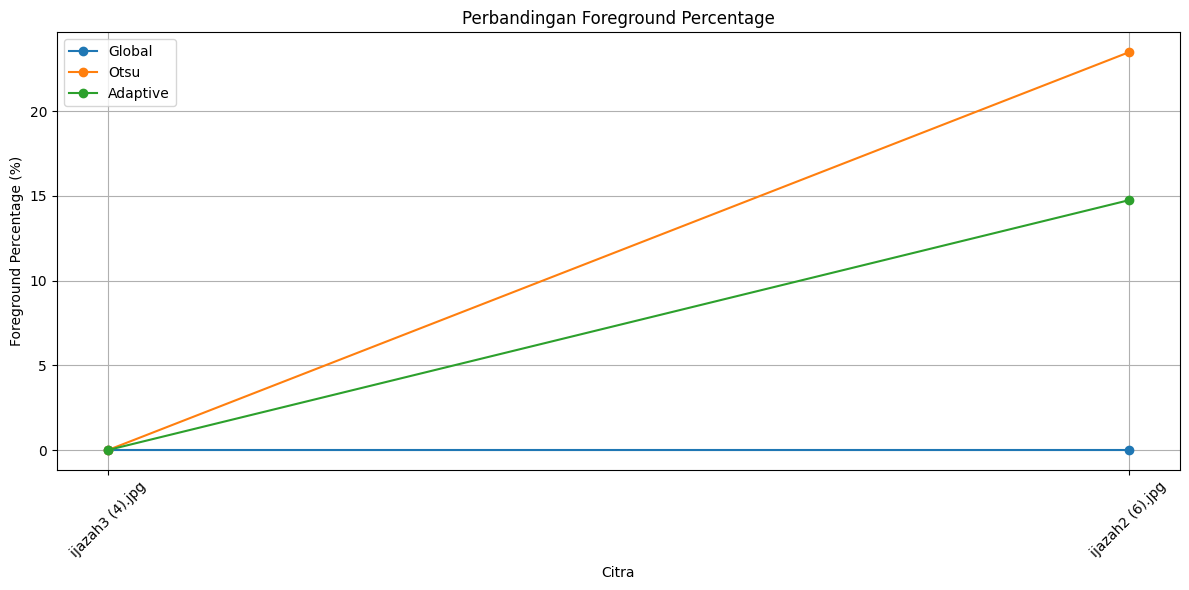

In [224]:
plt.figure(figsize=(12, 6))

for method in ["Global", "Otsu", "Adaptive"]:

    data = df_comparison[
        df_comparison["Method"] == method
    ]

    plt.plot(
        data["Image"],
        data["Foreground Percentage"],
        marker="o",
        label=method
    )

plt.xlabel("Citra")
plt.ylabel("Foreground Percentage (%)")
plt.title("Perbandingan Foreground Percentage")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [225]:
df_results.to_csv(
    "hasil_deteksi_tanda_tangan.csv",
    index=False
)

df_comparison.to_csv(
    "perbandingan_thresholding.csv",
    index=False
)

print("File hasil berhasil dibuat:")
print("- hasil_deteksi_tanda_tangan.csv")
print("- perbandingan_thresholding.csv")

File hasil berhasil dibuat:
- hasil_deteksi_tanda_tangan.csv
- perbandingan_thresholding.csv


## Analisis & Jawaban Pertanyaan

**Mengapa thresholding diperlukan sebelum melakukan analisis keberadaan tanda tangan?**

Thresholding diperlukan untuk memisahkan bagian foreground dan background pada area tanda tangan. Setelah citra dikonversi menjadi grayscale, setiap piksel masih memiliki nilai intensitas yang berbeda-beda sehingga keberadaan tanda tangan belum dapat dianalisis secara langsung.

Dengan thresholding, citra grayscale diubah menjadi citra biner yang terdiri dari foreground dan background. Pada penelitian ini, foreground dianggap sebagai piksel yang kemungkinan merupakan tinta tanda tangan, sedangkan background merupakan bagian kertas atau latar belakang. Hasil segmentasi tersebut kemudian dapat digunakan untuk menghitung jumlah piksel foreground atau persentase area foreground. Nilai tersebut menjadi dasar untuk menentukan apakah pada area yang diperiksa terdapat tanda tangan atau tidak.


**Apa masalah yang terjadi jika threshold terlalu tinggi atau terlalu rendah?**

**Threshold terlalu tinggi:** terlalu banyak piksel dianggap foreground — kertas, noise, tekstur, dan
watermark ikut terdeteksi, sehingga area kosong bisa salah menjadi PRESENT (false positive).
**Threshold terlalu rendah:** hanya piksel sangat gelap yang lolos; goresan tipis atau tinta terang
hilang/terputus, sehingga tanda tangan asli bisa salah menjadi ABSENT (false negative).
*(Catatan: arah ini berlaku untuk `THRESH_BINARY_INV`, yaitu piksel ≤ threshold menjadi foreground. Pada kode ini global threshold 127 yang "terlalu rendah" terbukti memberi 0% pada tanda tangan terang.)*